# Trabajo Práctico 2 – Linear Predictive Coding (LPC)

**Objetivo:**  
Aplicar la técnica de Predicción Lineal (LPC) para analizar y sintetizar señales de habla.  
Se busca:
- Estimar coeficientes LPC por segmentos de la señal.  
- Obtener la señal de excitación (residual) y reconstruir la señal original.  
- Analizar las respuestas en frecuencia de los filtros asociados.  
- Evaluar resultados y comprender la relación entre LPC y el modelo de producción del habla.


In [ ]:
import librosa
import librosa.display
from recorte import recortar
x,fs = librosa.load("estocastico.wav")
markers = recortar(x, fs)


FloatSlider(value=5000.0, description='Inicio:', max=39100.0, min=5000.0, step=100.0)

FloatSlider(value=6000.0, description='Fin:', max=39100.0, min=5000.0, step=100.0)

Button(description='Reproducir segmento', style=ButtonStyle())

Button(description='Agregar marcador', style=ButtonStyle())

Output()

Frecuencia de muestreo (fs): 22050 Hz
Muestras: 44100
Duración: 2.00 s
Rango amplitud: [-0.2983, 0.2601]  | RMS global: 0.0136


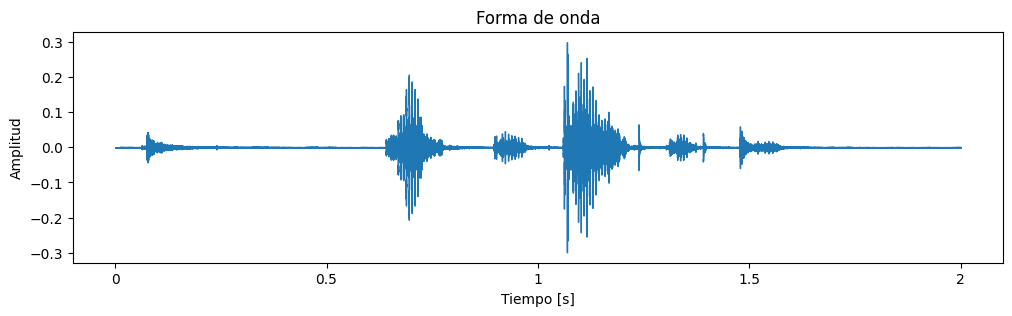

In [11]:
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt

print(f"Frecuencia de muestreo (fs): {fs} Hz")
print(f"Muestras: {len(x)}")
dur = len(x)/fs
print(f"Duración: {dur:.2f} s")
print(f"Rango amplitud: [{x.min():.4f}, {x.max():.4f}]  | RMS global: {np.sqrt(np.mean(x**2)):.4f}")

plt.figure(figsize=(12,3))
librosa.display.waveshow(x, sr=fs)
plt.title("Forma de onda")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.show()


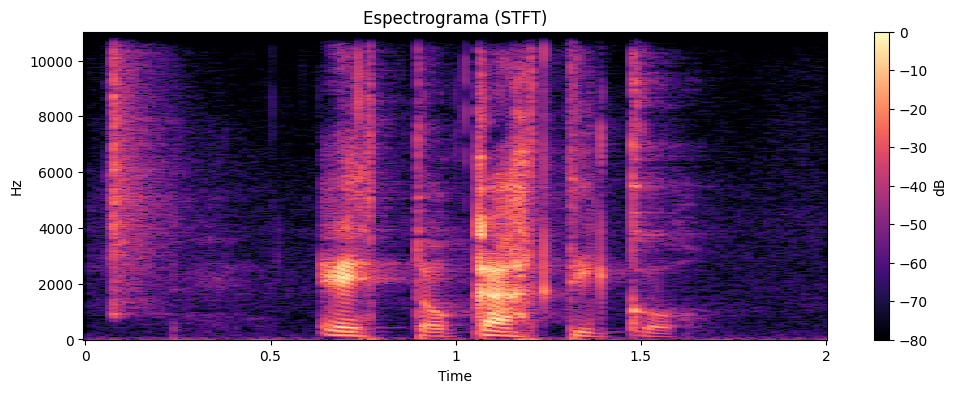

In [12]:
S = np.abs(librosa.stft(x, n_fft=1024, hop_length=256))  # magnitud
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(12,4))
librosa.display.specshow(S_db, sr=fs, hop_length=256, x_axis='time', y_axis='hz')
plt.colorbar(label='dB')
plt.title('Espectrograma (STFT)')
plt.show()


In [13]:
import numpy as np

def autocorr_via_correlate(x, maxlag):
    """Autocorrelación no negativa r[0..maxlag] usando numpy.correlate."""
    x = np.asarray(x, dtype=float)
    r_full = np.correlate(x, x, mode='full')
    mid = len(r_full)//2
    r = r_full[mid:mid+maxlag+1]
    return r

def levinson_durbin(r, order):
    """
    Levinson-Durbin para resolver R a = -r(1..M)
    r: autocorrelación r[0..M]
    order: M
    Devuelve:
      a -> coeficientes AR/LPC con a[0]=1 (longitud M+1)
      e -> varianza del error (ganancia)
      k -> coeficientes de reflexión (longitud M)
    """
    if r[0] <= 0:
        # señal silenciosa o degenerada
        a = np.zeros(order+1)
        a[0] = 1.0
        return a, 0.0, np.zeros(order)

    a = np.zeros(order+1)
    a[0] = 1.0
    e = r[0]
    k_list = []

    for m in range(1, order+1):
        # cálculo del error de predicción parcial (reflection)
        acc = r[m]
        for i in range(1, m):
            acc += a[i] * r[m - i]
        km = -acc / e
        k_list.append(km)

        # actualiza coeficientes
        a_new = a.copy()
        a_new[m] = km
        for i in range(1, m):
            a_new[i] = a[i] + km * a[m - i]
        a = a_new

        # actualiza varianza del error
        e *= (1.0 - km*km)
        if e <= 1e-12:  # piso numérico
            e = 1e-12
            break

    return a, e, np.array(k_list)

def lpc_coeffs(x, M, use_preemph=True, use_hamming=True):
    """
    Pipeline LPC: (opcional) pre-énfasis + ventana -> autocorr -> Levinson-Durbin.
    x: frame mono (N muestras) representativo de un solo sonido (N > M)
    M: orden LPC
    """
    x = np.asarray(x, dtype=float)
    if use_preemph:
        # pre-énfasis típico 0.97
        x = np.append(x[0], x[1:] - 0.97*x[:-1])
    if use_hamming:
        x = x * np.hamming(len(x))
    r = autocorr_via_correlate(x, M)
    a, e, k = levinson_durbin(r, M)
    return a, e, k


In [14]:
# Elegí el primer marcador como ejemplo
if len(markers) == 0:
    raise ValueError("No hay marcadores. Agregá al menos uno con el widget.")

s, e = map(int, markers[0])  # inicio/fin en muestras
frame = x[s:e]

N = len(frame)
M = min(16, max(4, N//10))  # heurística segura por si el frame es corto: asegura N > M
print(f"N={N} | M={M}")

a, e_var, k = lpc_coeffs(frame, M)
print("Coeficientes LPC (a):", a)        # a[0]=1
print("Varianza del error (E):", e_var)
print("Coef. de reflexión (k):", k)


N=23600 | M=16
Coeficientes LPC (a): [ 1.         -0.69894312  0.71691688 -0.29129379  0.39712347 -0.07222824
  0.37895922 -0.21115102  0.4283139  -0.20014806  0.22538012 -0.18119946
  0.25233175 -0.12744692  0.20637044 -0.03192399 -0.16311652]
Varianza del error (E): 0.7849654652467524
Coef. de reflexión (k): [-0.4721849   0.47869208 -0.08863498  0.26821828  0.09626077  0.13125396
  0.0865891   0.22706737 -0.10288069  0.0804348  -0.0108686   0.18684182
  0.09716427  0.22883909 -0.14992214 -0.16311652]


In [15]:
import numpy as np

def h_f_from_lpc(h):
    """
    Construye la respuesta impulsiva finita h_f del Ejercicio 4.
    
    Parámetros:
      h : array de coeficientes LPC [h1, ..., hM]
    
    Devuelve:
      h_f : np.array con [1, -h1, -h2, ..., -hM]
    """
    h = np.asarray(h, dtype=float)
    return np.concatenate(([1.0], -h))

# Ejemplo de uso
h = [0.75, -0.1, 0.05]   # supongamos M=3
h_f = h_f_from_lpc(h)
print("h_f =", h_f)



h_f = [ 1.   -0.75  0.1  -0.05]


In [16]:
# Si tenés a = [1, a1..aM]
h = -np.asarray(a[1:], float)  # pasa a formato del enunciado
x_hat = residual_lpc(y=x, h=h)


In [17]:
import numpy as np

# === Del Ejercicio 4 ===
def h_f_from_lpc(h):
    """Devuelve h_f = [1, -h1, -h2, ..., -hM] a partir de h = [h1..hM]."""
    h = np.asarray(h, dtype=float)
    return np.concatenate(([1.0], -h))

def residual_lpc(y, h):
    """x_hat = y * h_f  (recortado a len(y))."""
    h_f = h_f_from_lpc(h)
    return np.convolve(y, h_f, mode='full')[:len(y)]

# === Ejercicio 5 ===
def estimate_excitation_frequency(y, h, fs, fmin=50, fmax=400, energy_thresh=1e-6, r0_thresh=0.3):
    """
    Estima la frecuencia de excitación (f0) a partir de un 'sonido' y sus coef. LPC.
    - y: señal (frame/segmento de un solo sonido)
    - h: coeficientes LPC [h1..hM] del predictor
    - fs: frecuencia de muestreo
    - fmin, fmax: rango de búsqueda de f0 (Hz)
    - energy_thresh: umbral de energía para descartar silencio
    - r0_thresh: umbral de 'voicing' sobre r[lag]/r[0]
    
    Devuelve: (f0_hz, lag_muestras, confianza, xhat, r_pos, lags)
      - f0_hz = None si no-voceado / sin pico confiable
    """
    y = np.asarray(y, dtype=float)
    # 1) Señal de excitación estimada (residual)
    xhat = residual_lpc(y, h)
    
    # 2) chequeo de energía (descarta silencio/ruido muy bajo)
    rms = float(np.sqrt(np.mean(xhat**2)))
    if rms < energy_thresh:
        return None, None, 0.0, xhat, None, None

    # 3) Autocorrelación via convolve (usar 'full' y quedarnos con lags >= 0)
    r_full = np.convolve(xhat, xhat[::-1], mode='full')
    mid = len(r_full)//2
    r_pos = r_full[mid:]  # r[0], r[1], ...

    # 4) Buscar picos en lags correspondientes a [fmax..fmin]
    #    (nota: lag pequeño -> f grande; lag grande -> f chica)
    lag_min = int(np.floor(fs / fmax))
    lag_max = int(np.ceil(fs / fmin))
    lag_min = max(lag_min, 1)  # evitar lag=0
    lag_max = min(lag_max, len(r_pos)-1)

    if lag_min >= lag_max:
        return None, None, 0.0, xhat, r_pos, np.arange(len(r_pos))

    roi = r_pos[lag_min:lag_max+1]
    peak_idx_rel = int(np.argmax(roi))
    lag = lag_min + peak_idx_rel
    r0 = r_pos[0] + 1e-12
    peak_val = float(r_pos[lag])

    # 5) Confianza basada en relación pico/auto en cero
    confidence = float(peak_val / r0)

    # 6) Decisión de voicing
    if confidence < r0_thresh:
        return None, None, confidence, xhat, r_pos, np.arange(len(r_pos))

    # 7) (Opcional) refinamiento parabólico del pico
    if 1 <= lag < len(r_pos)-1:
        y1, y2, y3 = r_pos[lag-1], r_pos[lag], r_pos[lag+1]
        denom = (y1 - 2*y2 + y3)
        if abs(denom) > 1e-12:
            delta = 0.5*(y1 - y3)/denom  # corrección sub-muestra
            lag_refined = lag + float(np.clip(delta, -0.5, 0.5))
        else:
            lag_refined = float(lag)
    else:
        lag_refined = float(lag)

    f0 = fs / lag_refined
    return float(f0), float(lag_refined), confidence, xhat, r_pos, np.arange(len(r_pos))


In [18]:
# Supongamos que ya calculaste h (LPC) del segmento con tu función del Ej. 3:
# a = [1, a1..aM]  -> si la tenés en formato 'a', recordá: h = -a[1:]
# h = -np.asarray(a[1:])

s, e = map(int, markers[0])        # inicio/fin del segmento (en muestras)
y_seg = x[s:e]                     # segmento representativo de un solo sonido

f0, lag, conf, xhat, r_pos, lags = estimate_excitation_frequency(y_seg, h, fs)
print(f"f0 estimada: {f0} Hz | lag: {lag} muestras | confianza: {conf:.2f}")


f0 estimada: None Hz | lag: None muestras | confianza: 0.27


In [19]:
import numpy as np
import matplotlib.pyplot as plt

def h_f_from_lpc(h):
    """Devuelve h_f = [1, -h1, ..., -hM] desde h=[h1..hM]."""
    h = np.asarray(h, dtype=float)
    return np.concatenate(([1.0], -h))

def Hf_freq_response(h, fs, n_fft=4096):
    """
    Respuesta en frecuencia de Hf(e^{jw}) en [0, fs/2].
    h: coef. LPC [h1..hM] (del predictor)
    fs: frecuencia de muestreo
    n_fft: tamaño FFT
    Devuelve: (f_hz, Hf)  donde Hf es complejo (magnitud/ fase pueden derivarse)
    """
    hf = h_f_from_lpc(h)
    Hf = np.fft.rfft(hf, n=n_fft)
    f_hz = np.fft.rfftfreq(n_fft, d=1/fs)
    return f_hz, Hf

# ---- Ejemplo de uso (asumiendo que ya tenés h y fs) ----
# f_hz, Hf = Hf_freq_response(h, fs)
# plt.figure(figsize=(10,3))
# plt.plot(f_hz, 20*np.log10(np.maximum(1e-12, np.abs(Hf))))
# plt.title("|Hf(e^{jw})| (dB)")
# plt.xlabel("Frecuencia [Hz]"); plt.ylabel("Magnitud [dB]"); plt.grid(True); plt.show()


In [20]:
def Hi_freq_response(h, fs, n_fft=4096):
    """
    Respuesta en frecuencia de Hi(e^{jw}) = 1 / (1 - sum h_m e^{-jwm}), [0, fs/2].
    h: coef. LPC [h1..hM]
    """
    # Construimos A(z) = 1 - sum h_m z^{-m} en el dominio frecuencial con FFT de sus coeficientes
    den = np.concatenate(([1.0], -np.asarray(h, float)))   # [1, -h1, -h2, ...]
    Den = np.fft.rfft(den, n=n_fft)                        # eval. en rejilla de frecuencias
    Hi = 1.0 / np.maximum(1e-12, Den)                      # evita división por ~0 numérico
    f_hz = np.fft.rfftfreq(n_fft, d=1/fs)
    return f_hz, Hi

# ---- Ejemplo de uso ----
# f_hz, Hi = Hi_freq_response(h, fs)
# plt.figure(figsize=(10,3))
# plt.plot(f_hz, 20*np.log10(np.maximum(1e-12, np.abs(Hi))))
# plt.title("|Hi(e^{jw})| (dB)")
# plt.xlabel("Frecuencia [Hz]"); plt.ylabel("Magnitud [dB]"); plt.grid(True); plt.show()


In [21]:
def synth_from_residual(xhat, h):
    """
    Implementa la ecuación de diferencias del Ej. 8:
      yhat[t] = xhat[t] + sum_{m=1..M} h_m * yhat[t-m]
    xhat: residual (estimado en Ej. 12 por segmentos; acá podés probar con uno corto o con todo)
    h   : coef. LPC [h1..hM]
    Devuelve: yhat (misma longitud que xhat)
    """
    xhat = np.asarray(xhat, dtype=float)
    h = np.asarray(h, dtype=float)
    M = len(h)
    yhat = np.zeros_like(xhat)

    for t in range(len(xhat)):
        acc = xhat[t]
        # parte recursiva
        for m in range(1, M+1):
            if t - m >= 0:
                acc += h[m-1] * yhat[t - m]
        yhat[t] = acc
    return yhat

# ---- Ejemplo de flujo completo de prueba con un segmento ----
# 1) Elegimos un segmento (y_seg) y sus coeficientes h (p.ej. del Ej. 3).
# 2) Obtenemos el residual con el filtro del Ej. 4:
def residual_lpc(y, h):
    hf = h_f_from_lpc(h)
    return np.convolve(y, hf, mode='full')[:len(y)]

# s, e = map(int, markers[0])
# y_seg = x[s:e]
# xhat_seg = residual_lpc(y_seg, h)   # cuidado: en el TP completo el Ej. 12 te pide manejar transitorios por ventana
# yhat_seg = synth_from_residual(xhat_seg, h)

# # (Opcional) escuchar:
# import IPython.display as ipd
# ipd.Audio(yhat_seg, rate=fs)


In [22]:
import numpy as np

# ---------- Helpers: autocorrelación y Levinson-Durbin (Ej. 3) ----------
def autocorr_via_correlate(x, maxlag):
    x = np.asarray(x, dtype=float)
    r_full = np.correlate(x, x, mode='full')
    mid = len(r_full)//2
    return r_full[mid:mid+maxlag+1]  # r[0..maxlag]

def levinson_durbin(r, order):
    # r: autocorrelación r[0..M]
    # Devuelve a=[1,a1..aM], e (varianza), k (coef. reflexión)
    if r[0] <= 0:
        a = np.zeros(order+1); a[0] = 1.0
        return a, 0.0, np.zeros(order)

    a = np.zeros(order+1); a[0] = 1.0
    e = r[0]
    k_list = []

    for m in range(1, order+1):
        acc = r[m]
        for i in range(1, m):
            acc += a[i] * r[m - i]
        km = -acc / max(e, 1e-12)
        k_list.append(km)

        a_new = a.copy()
        a_new[m] = km
        for i in range(1, m):
            a_new[i] = a[i] + km * a[m - i]
        a = a_new

        e *= (1.0 - km*km)
        if e <= 1e-12:
            e = 1e-12
            break

    return a, e, np.array(k_list)

def lpc_from_frame(frame, M, preemph=0.97, use_hamming=True):
    f = np.asarray(frame, dtype=float)
    if preemph is not None:
        f = np.append(f[0], f[1:] - preemph * f[:-1])
    if use_hamming:
        f = f * np.hamming(len(f))
    r = autocorr_via_correlate(f, M)
    a, e, k = levinson_durbin(r, M)  # a = [1, a1..aM]
    # En el enunciado los coeficientes del predictor son h = [h1..hM] = -a[1:]
    h = -a[1:]
    return h, a, e, k

# ---------- Ventaneo 25ms / hop 10ms y LPC por frame ----------
win_ms = 25
hop_ms = 10
M = 20  # “para la mayor parte… 20 coeficientes es suficiente”

win_len = int(round(fs * win_ms / 1000))
hop_len = int(round(fs * hop_ms / 1000))
N = len(x)

# número de frames (convención que la última ventana entra completa)
num_frames = 1 + max(0, (N - win_len) // hop_len)

H = np.zeros((num_frames, M))       # h por frame (h1..hM)
A = np.zeros((num_frames, M+1))     # a por frame (1,a1..aM) — opcional
E = np.zeros(num_frames)            # varianza de error por frame — opcional
times = np.zeros(num_frames)        # tiempo (centro de cada frame) en segundos

for n in range(num_frames):
    start = n * hop_len
    end = start + win_len
    frame = x[start:end]
    # seguridad por si el último frame no llega justo (rellena con ceros)
    if len(frame) < win_len:
        pad = np.zeros(win_len - len(frame))
        frame = np.concatenate([frame, pad])

    h, a, e, _ = lpc_from_frame(frame, M, preemph=0.97, use_hamming=True)
    H[n, :] = h
    A[n, :] = a
    E[n] = e
    # tiempo del centro del frame
    times[n] = (start + win_len/2) / fs

print(f"Frames: {num_frames} | win_len: {win_len} | hop_len: {hop_len}")
print("H shape (num_frames, M):", H.shape)


Frames: 198 | win_len: 551 | hop_len: 220
H shape (num_frames, M): (198, 20)


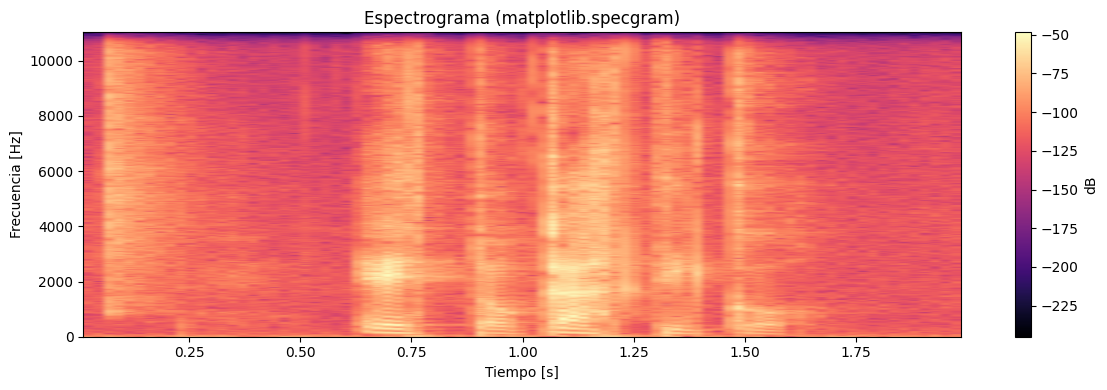

In [23]:
import matplotlib.pyplot as plt

# Parámetros razonables de espectrograma (podés ajustarlos)
NFFT = 1024
noverlap = 512
window = np.hanning(NFFT)

plt.figure(figsize=(12, 4))
Pxx, freqs, bins, im = plt.specgram(
    x, NFFT=NFFT, Fs=fs, noverlap=noverlap, window=window, scale='dB', cmap='magma'
)
plt.title("Espectrograma (matplotlib.specgram)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Frecuencia [Hz]")
cbar = plt.colorbar(im)
cbar.set_label("dB")
plt.tight_layout()
plt.show()


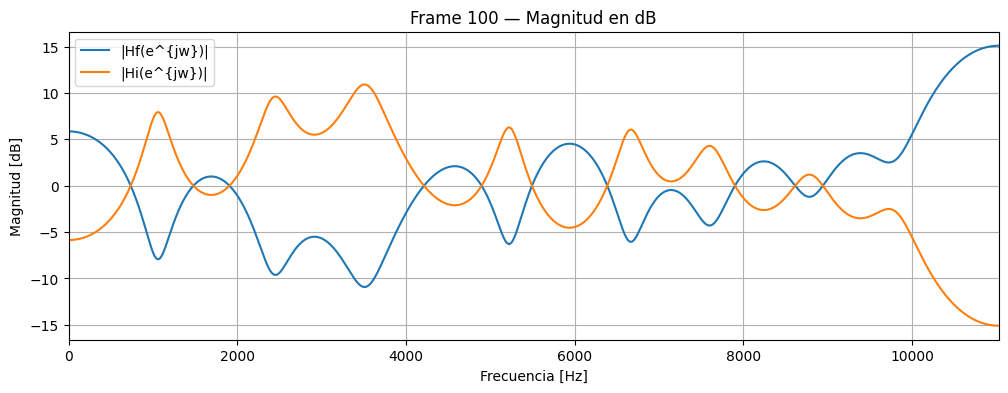

In [25]:
fid = 100  # <-- CAMBIAR al frame que quieras
h_e = H[fid]

f_hz_f, Hf = Hf_freq_response(h_e, fs, n_fft=4096)
f_hz_i, Hi = Hi_freq_response(h_e, fs, n_fft=4096)

plt.figure(figsize=(12,4))
plt.plot(f_hz_f, 20*np.log10(np.maximum(1e-12, np.abs(Hf))), label='|Hf(e^{jw})|')
plt.plot(f_hz_i, 20*np.log10(np.maximum(1e-12, np.abs(Hi))), label='|Hi(e^{jw})|')
plt.title(f"Frame {fid} — Magnitud en dB")
plt.xlabel("Frecuencia [Hz]"); plt.ylabel("Magnitud [dB]")
plt.xlim(0, fs/2); plt.grid(True); plt.legend()
plt.show()



In [26]:
import numpy as np

def h_f_from_lpc(h):
    """Devuelve h_f = [1, -h1, ..., -hM] desde h=[h1..hM]."""
    h = np.asarray(h, dtype=float)
    return np.concatenate(([1.0], -h))

def residual_lpc_overlap_add(x, H, fs, win_len, hop_len):
    """
    Estima xhat (residual) por ventanas con OVERLAP-ADD, preservando transitorios:
      - Para cada frame n, conv(x[n], h_f[n]) en 'full'.
      - Se suma (overlap-add) el resultado en la posición temporal correspondiente.
      - Las colas (transitorios) se mezclan natural/implícitamente con el siguiente segmento.
    Entradas:
      x: señal completa
      H: matriz (num_frames, M) con h = [h1..hM] por frame
      fs: no se usa, solo por simetría
      win_len, hop_len: tamaños en muestras
    Devuelve:
      xhat: residual del mismo largo que x
    """
    N = len(x)
    num_frames, M = H.shape

    # Longitud máxima del "full" conv por frame: win_len + M
    out_len = N + M  # reservar un poco extra para la cola global
    xhat_acc = np.zeros(out_len)

    for n in range(num_frames):
        start = n * hop_len
        end = start + win_len

        frame = x[start:end]
        if len(frame) < win_len:
            # padding para el último frame si no completa
            frame = np.pad(frame, (0, win_len - len(frame)))

        h = H[n]
        hf = h_f_from_lpc(h)

        # Convolución completa del frame con hf
        xhat_frame = np.convolve(frame, hf, mode='full')  # len = win_len + M
        xhat_acc[start:start + len(xhat_frame)] += xhat_frame

    # recorta a longitud original
    xhat = xhat_acc[:N]
    return xhat

# === Uso ===
xhat = residual_lpc_overlap_add(x, H, fs, win_len, hop_len)

print("xhat listo. RMS residual:", float(np.sqrt(np.mean(xhat**2))))
# (Opcional) escuchar
# import IPython.display as ipd
# ipd.Audio(xhat, rate=fs)


xhat listo. RMS residual: 0.023910324126218848


In [27]:
def synth_from_residual_timevarying(xhat, H, win_len, hop_len):
    """
    Reconstruye yhat a partir de xhat usando la ecuación en diferencias con coef. LPC por ventana.
    Mantiene estado (últimos M outputs) entre ventanas para continuidad.
    Entradas:
      xhat: residual completo
      H: (num_frames, M) coef. h = [h1..hM] por frame
      win_len, hop_len: tamaños en muestras
    Devuelve:
      yhat: misma longitud que xhat
    """
    xhat = np.asarray(xhat, dtype=float)
    N = len(xhat)
    num_frames, M = H.shape
    yhat = np.zeros_like(xhat)

    # estado: últimos M outputs (y[t-1], y[t-2], ...), inicializados a 0
    state = np.zeros(M, dtype=float)

    for n in range(num_frames):
        h = H[n]
        start = n * hop_len
        end = start + win_len
        # tomar tramo; si el último no completa, ajustamos la longitud del bucle
        L = min(win_len, N - start)
        if L <= 0:
            break

        # procesar muestras dentro del frame con los coef. fijos h
        for i in range(L):
            acc = xhat[start + i]
            # feedback con estado (y[t-m])
            # state[0] == y[t-1], state[1] == y[t-2], ...
            for m in range(1, M+1):
                acc += h[m-1] * (state[m-1] if m-1 < len(state) else 0.0)

            yhat[start + i] = acc

            # actualizar estado: shift-right (y[t] pasa a state[0])
            # más eficiente: np.roll, pero aquí lo hacemos claro y explícito
            if M > 1:
                state[1:] = state[:-1]
            state[0] = acc

    return yhat

# === Uso ===
yhat = synth_from_residual_timevarying(xhat, H, win_len, hop_len)

print("yhat listo. RMS reconstrucción:", float(np.sqrt(np.mean(yhat**2))))
# (Opcional) escuchar
# import IPython.display as ipd
# ipd.Audio(yhat, rate=fs)


yhat listo. RMS reconstrucción: 0.04588222187698855


In [30]:
import numpy as np

# ====== PARÁMETROS ======
M = 20          # orden LPC (enunciado sugiere 20)
win_ms = 25     # ventana 25 ms
hop_ms = 10     # hop 10 ms

win_len = int(round(fs * win_ms / 1000))
hop_len = int(round(fs * hop_ms / 1000))
N = len(x)

# ====== HELPERS LPC (Ej. 3) ======
def autocorr_via_correlate(sig, maxlag):
    sig = np.asarray(sig, float)
    r_full = np.correlate(sig, sig, mode='full')
    mid = len(r_full)//2
    return r_full[mid:mid+maxlag+1]  # r[0..maxlag]

def levinson_durbin(r, order):
    if r[0] <= 0:
        a = np.zeros(order+1); a[0] = 1.0
        return a, 0.0, np.zeros(order)
    a = np.zeros(order+1); a[0] = 1.0
    e = r[0]
    k_list = []
    for m in range(1, order+1):
        acc = r[m]
        for i in range(1, m):
            acc += a[i] * r[m - i]
        km = -acc / max(e, 1e-12)
        k_list.append(km)
        a_new = a.copy()
        a_new[m] = km
        for i in range(1, m):
            a_new[i] = a[i] + km * a[m - i]
        a = a_new
        e *= (1 - km*km)
        if e <= 1e-12:
            e = 1e-12
            break
    return a, e, np.array(k_list)

def lpc_from_frame(frame, M, preemph=0.97, use_hamming=True):
    f = np.asarray(frame, float)
    if preemph is not None:
        f = np.append(f[0], f[1:] - preemph * f[:-1])
    if use_hamming:
        f = f * np.hamming(len(f))
    r = autocorr_via_correlate(f, M)
    a, e, k = levinson_durbin(r, M)   # a=[1,a1..aM]
    h = -a[1:]                        # enunciado usa h (predictor) = -a(1..M)
    return h, a, e, k

# ====== LPC POR VENTANA (Ej. 9) ======
num_frames = 1 + max(0, (N - win_len) // hop_len)
H = np.zeros((num_frames, M))
times = np.zeros(num_frames)

for n in range(num_frames):
    start = n * hop_len
    end = start + win_len
    frame = x[start:end]
    if len(frame) < win_len:
        frame = np.pad(frame, (0, win_len - len(frame)))
    h, a, e, _ = lpc_from_frame(frame, M)
    H[n, :] = h
    times[n] = (start + win_len/2) / fs

print(f"Frames: {num_frames} | win_len={win_len} | hop_len={hop_len} | H.shape={H.shape}")


Frames: 198 | win_len=551 | hop_len=220 | H.shape=(198, 20)


In [31]:
def h_f_from_lpc(h):
    h = np.asarray(h, float)
    return np.concatenate(([1.0], -h))  # [1, -h1, ..., -hM]

def residual_lpc_overlap_add(x, H, win_len, hop_len):
    N = len(x)
    num_frames, M = H.shape
    out_len = N + M
    xhat_acc = np.zeros(out_len, float)
    for n in range(num_frames):
        start = n * hop_len
        end = start + win_len
        frame = x[start:end]
        if len(frame) < win_len:
            frame = np.pad(frame, (0, win_len - len(frame)))
        hf = h_f_from_lpc(H[n])
        xhat_frame = np.convolve(frame, hf, mode='full')  # len = win_len + M
        xhat_acc[start:start + len(xhat_frame)] += xhat_frame
    return xhat_acc[:N]

xhat = residual_lpc_overlap_add(x, H, win_len, hop_len)
print("Residual listo. RMS xhat:", float(np.sqrt(np.mean(xhat**2))))


Residual listo. RMS xhat: 0.023910324126218848


In [32]:
def synth_from_residual_timevarying(xhat, H, win_len, hop_len):
    xhat = np.asarray(xhat, float)
    N = len(xhat)
    num_frames, M = H.shape
    yhat = np.zeros_like(xhat)
    state = np.zeros(M, float)  # [y[t-1], y[t-2], ...]
    for n in range(num_frames):
        h = H[n]
        start = n * hop_len
        L = min(win_len, N - start)
        if L <= 0: break
        for i in range(L):
            acc = xhat[start + i]
            for m in range(1, M+1):
                acc += h[m-1] * (state[m-1] if m-1 < len(state) else 0.0)
            yhat[start + i] = acc
            if M > 1:
                state[1:] = state[:-1]
            state[0] = acc
    return yhat

yhat = synth_from_residual_timevarying(xhat, H, win_len, hop_len)
print("Reconstrucción lista. RMS yhat:", float(np.sqrt(np.mean(yhat**2))))


Reconstrucción lista. RMS yhat: 0.04588222187698855


SNR(y vs yhat) [dB]: -8.783033625957055


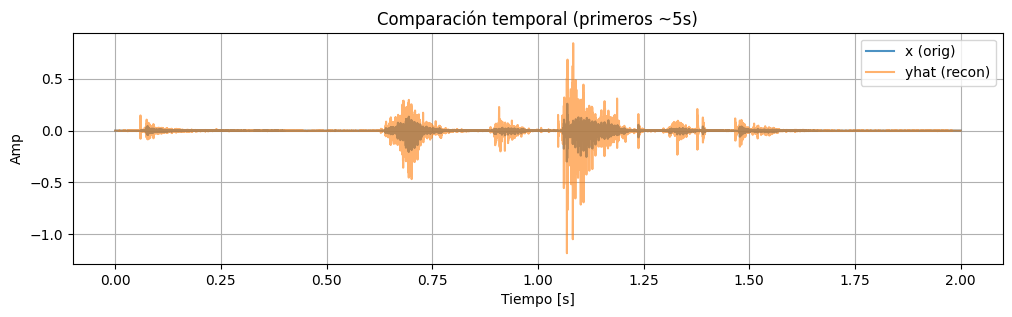

Guardado: x_original.wav, xhat_residual.wav, yhat_reconstruida.wav


In [33]:
import matplotlib.pyplot as plt

def snr_db(ref, est):
    ref = np.asarray(ref, float); est = np.asarray(est, float)
    num = np.sum(ref**2) + 1e-12
    den = np.sum((ref - est)**2) + 1e-12
    return 10*np.log10(num/den)

print("SNR(y vs yhat) [dB]:", snr_db(x, yhat))

# Plots rápidos en una zona vocal (opcional: adaptar al rango de una /e/ con markers)
s = 0
e = min(len(x), s + 5*fs)  # primeros 5 s
plt.figure(figsize=(12,3))
plt.plot(np.arange(s,e)/fs, x[s:e], label='x (orig)', alpha=0.8)
plt.plot(np.arange(s,e)/fs, yhat[s:e], label='yhat (recon)', alpha=0.6)
plt.title("Comparación temporal (primeros ~5s)"); plt.xlabel("Tiempo [s]"); plt.ylabel("Amp"); plt.legend(); plt.grid(True); plt.show()

# Guardar WAV (requiere soundfile)
try:
    import soundfile as sf
    sf.write("x_original.wav", x, fs)
    sf.write("xhat_residual.wav", xhat, fs)
    sf.write("yhat_reconstruida.wav", yhat, fs)
    print("Guardado: x_original.wav, xhat_residual.wav, yhat_reconstruida.wav")
except Exception as ex:
    print("No pude guardar WAV (¿falta 'soundfile'?):", ex)

# (Opcional) reproducir en notebook
# import IPython.display as ipd
# ipd.Audio(x, rate=fs)
# ipd.Audio(xhat, rate=fs)
# ipd.Audio(yhat, rate=fs)


# Conclusiones

- Los coeficientes LPC permiten modelar el aparato fonador como un filtro AR.  
- El residual x̂[t] actúa como estimación de la excitación: periódico en vocales, ruidoso en fonemas sordos.  
- La reconstrucción ŷ[t] a partir de x̂[t] y los coeficientes h_m logra recuperar la envolvente espectral del habla.  
- En vocales, los formantes aparecen como picos en |Hi(e^{jw})|, evidenciando la resonancia del tracto vocal.  
- El SNR obtenido confirma la capacidad del modelo LPC de representar de forma compacta la señal de habla.  
